Project Idea: Using PCA to refine the structural representation of age asymmetry, I cluster relationship profiles, identify extreme/outlier profiles, and examine whether extremes vary by decade and production recurrence (actor/director frequency).

Name: Yun Hsuan Ku

#Import Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2023/2023-02-14/age_gaps.csv"
age_gaps = pd.read_csv(url)

age_gaps.columns = age_gaps.columns.str.lower()

# parse dates
date_cols = [c for c in age_gaps.columns if "birthdate" in c]
for c in date_cols:
    age_gaps[c] = pd.to_datetime(age_gaps[c], errors="coerce")

age_gaps.head()

,movie_name,release_year,director,age_difference,couple_number,actor_1_name,actor_2_name,character_1_gender,character_2_gender,actor_1_birthdate,actor_2_birthdate,actor_1_age,actor_2_age
0,Harold and Maude,1971,Hal Ashby,52,1,Ruth Gordon,Bud Cort,woman,man,1896-10-30,1948-03-29,75,23
1,Venus,2006,Roger Michell,50,1,Peter O'Toole,Jodie Whittaker,man,woman,1932-08-02,1982-06-03,74,24
2,The Quiet American,2002,Phillip Noyce,49,1,Michael Caine,Do Thi Hai Yen,man,woman,1933-03-14,1982-10-01,69,20
3,The Big Lebowski,1998,Joel Coen,45,1,David Huddleston,Tara Reid,man,woman,1930-09-17,1975-11-08,68,23
4,Beginners,2010,Mike Mills,43,1,Christopher Plummer,Goran Visnjic,man,man,1929-12-13,1972-09-09,81,38


#EDA & Data preprocessing

In [2]:
age_gaps.isna().sum()

,0
movie_name,0
release_year,0
director,0
age_difference,0
couple_number,0
actor_1_name,0
actor_2_name,0
character_1_gender,0
character_2_gender,0
actor_1_birthdate,0


In [3]:
age_gaps_copy = age_gaps.copy()
age_gaps_copy=age_gaps_copy.drop(columns=['actor_1_birthdate', 'actor_2_birthdate', 'couple_number'])

In [4]:
age_gaps_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1155 entries, 0 to 1154
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   movie_name          1155 non-null   object
 1   release_year        1155 non-null   int64 
 2   director            1155 non-null   object
 3   age_difference      1155 non-null   int64 
 4   actor_1_name        1155 non-null   object
 5   actor_2_name        1155 non-null   object
 6   character_1_gender  1155 non-null   object
 7   character_2_gender  1155 non-null   object
 8   actor_1_age         1155 non-null   int64 
 9   actor_2_age         1155 non-null   int64 
dtypes: int64(4), object(6)
memory usage: 90.4+ KB


##Feature engineering

In [5]:
#Add new feature: actor frequency
actors = pd.concat([age_gaps_copy["actor_1_name"], age_gaps_copy["actor_2_name"]]).dropna()
actor_counts = actors.value_counts()

age_gaps_copy["actor_1_freq"] = age_gaps_copy["actor_1_name"].map(actor_counts).fillna(0)
age_gaps_copy["actor_2_freq"] = age_gaps_copy["actor_2_name"].map(actor_counts).fillna(0)

age_gaps_copy["actor_freq_sum"] = (
    age_gaps_copy["actor_1_freq"] + age_gaps_copy["actor_2_freq"]
)

# add new feature: director frequency
director_col = "director"
director_counts = age_gaps_copy[director_col].value_counts()

age_gaps_copy["director_freq"] = (
    age_gaps_copy[director_col].map(director_counts).fillna(0)
)

#Add new feature: younger_age
age_gaps_copy['younger_age'] = age_gaps_copy[['actor_1_age', 'actor_2_age']].min(axis=1)

#Add new feature: older_age
age_gaps_copy['order_age'] = age_gaps_copy[['actor_1_age', 'actor_2_age']].max(axis=1)

#Add new feature: mean_age_of_couple
age_gaps_copy['mean_age_of_couple'] = (age_gaps_copy['younger_age'] + age_gaps_copy['order_age'])/2

# add new column named " relative_age_gap"
age_gaps_copy['relative_age_gap'] = age_gaps_copy['age_difference']/age_gaps_copy['younger_age']

#Add new feature: relationship_type
age_gaps_copy["relationship_type"] = np.where(
    age_gaps_copy["character_1_gender"] == age_gaps_copy["character_2_gender"],
    "Same-gender",
    "Heterosexual"
)

#Add new feature: who_is_older
age_gaps_copy["who_is_older"] = np.where(
    age_gaps_copy["relationship_type"] != "Heterosexual",
   "Same-gender",
    np.where(
        age_gaps_copy["actor_1_age"] > age_gaps_copy["actor_2_age"],
        age_gaps_copy["character_1_gender"],
        np.where(
            age_gaps_copy["actor_2_age"] > age_gaps_copy["actor_1_age"],
            age_gaps_copy["character_2_gender"],
            "same_age"
        )
    )
)

#Add new feature: by_decade
age_gaps_copy["by_decade"] = (age_gaps_copy["release_year"] // 10) * 10

In [6]:
age_gaps_copy.head()

,movie_name,release_year,director,age_difference,actor_1_name,actor_2_name,character_1_gender,character_2_gender,actor_1_age,actor_2_age,...,actor_2_freq,actor_freq_sum,director_freq,younger_age,order_age,mean_age_of_couple,relative_age_gap,relationship_type,who_is_older,by_decade
0,Harold and Maude,1971,Hal Ashby,52,Ruth Gordon,Bud Cort,woman,man,75,23,...,1,2,1,23,75,49.0,2.260870,Heterosexual,woman,1970
1,Venus,2006,Roger Michell,50,Peter O'Toole,Jodie Whittaker,man,woman,74,24,...,1,2,3,24,74,49.0,2.083333,Heterosexual,man,2000
2,The Quiet American,2002,Phillip Noyce,49,Michael Caine,Do Thi Hai Yen,man,woman,69,20,...,2,3,2,20,69,44.5,2.450000,Heterosexual,man,2000
3,The Big Lebowski,1998,Joel Coen,45,David Huddleston,Tara Reid,man,woman,68,23,...,2,3,5,23,68,45.5,1.956522,Heterosexual,man,1990
4,Beginners,2010,Mike Mills,43,Christopher Plummer,Goran Visnjic,man,man,81,38,...,1,3,2,38,81,59.5,1.131579,Same-gender,Same-gender,2010


In [7]:
age_gaps_copy.describe()

,release_year,age_difference,actor_1_age,actor_2_age,actor_1_freq,actor_2_freq,actor_freq_sum,director_freq,younger_age,order_age,mean_age_of_couple,relative_age_gap,by_decade
count,1155.000000,1155.000000,1155.000000,1155.000000,1155.000000,1155.000000,1155.000000,1155.000000,1155.000000,1155.000000,1155.000000,1155.000000,1155.000000
mean,2000.799134,10.424242,40.635498,30.211255,5.528139,4.225974,9.754113,4.129004,30.211255,40.635498,35.423377,0.375871,1995.939394
std,16.365819,8.511086,10.424173,7.495952,5.429382,3.808458,6.553220,3.607927,7.495952,10.424173,8.019769,0.344632,16.380859
min,1935.000000,0.000000,18.000000,17.000000,1.000000,1.000000,2.000000,1.000000,17.000000,18.000000,18.000000,0.000000,1930.000000
25%,1997.000000,4.000000,33.000000,25.000000,2.000000,1.000000,4.000000,2.000000,25.000000,33.000000,30.000000,0.121951,1990.000000
50%,2004.000000,8.000000,39.000000,29.000000,4.000000,3.000000,8.000000,3.000000,29.000000,39.000000,34.500000,0.281250,2000.000000
75%,2012.000000,15.000000,47.000000,34.000000,7.000000,6.000000,14.000000,5.000000,34.000000,47.000000,39.750000,0.533333,2010.000000
max,2022.000000,52.000000,81.000000,68.000000,27.000000,27.000000,39.000000,20.000000,68.000000,81.000000,69.000000,2.470588,2020.000000


In [8]:
#build cluster matrix
cluster_features = [
    "age_difference",
    "relative_age_gap",
    "mean_age_of_couple",
    "younger_age",
    "order_age"
]
cluster_df = age_gaps_copy[cluster_features].copy()

In [9]:
#Checking Feature Correlation
age_gaps_copy[cluster_features].corr()

,age_difference,relative_age_gap,mean_age_of_couple,younger_age,order_age
age_difference,1.000000,0.946756,0.384386,-0.156465,0.703963
relative_age_gap,0.946756,1.000000,0.165136,-0.360809,0.513548
mean_age_of_couple,0.384386,0.165136,1.000000,0.851659,0.926265
younger_age,-0.156465,-0.360809,0.851659,1.000000,0.591344
order_age,0.703963,0.513548,0.926265,0.591344,1.000000


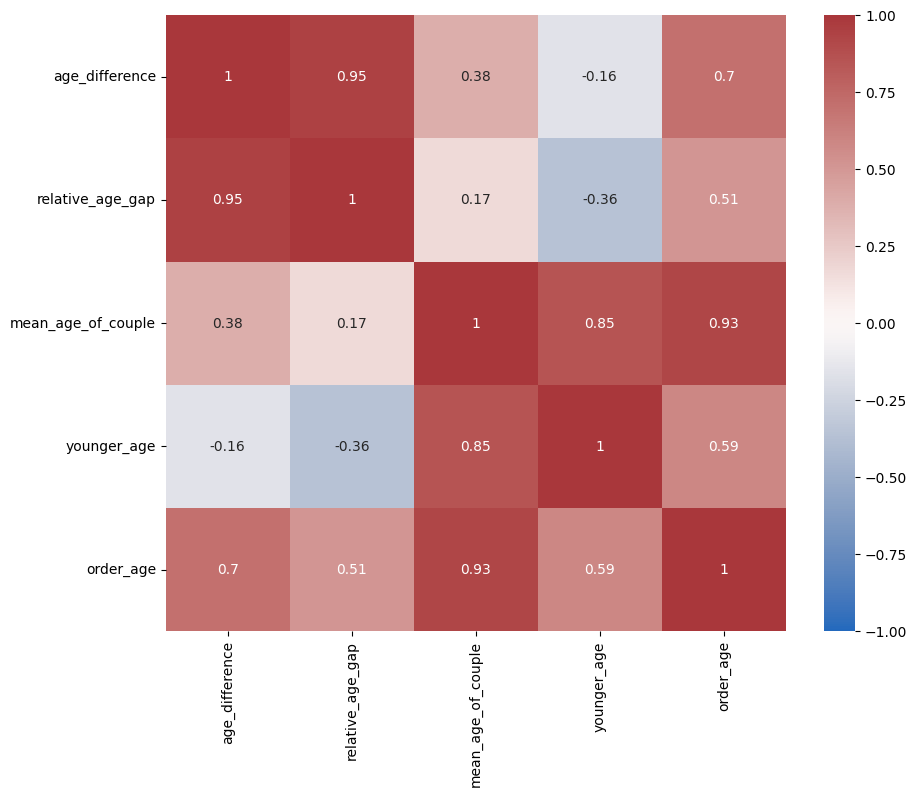

In [10]:
#Correlation Plot
import seaborn as sns
import matplotlib.pyplot as plt

corr = cluster_df[cluster_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="vlag", vmin=-1, vmax=1)
plt.show()

##Feature Normalization

In [11]:
#Standardize df features
X = age_gaps_copy[cluster_features]

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_normalized = scaler.fit_transform(X)

In [12]:
df_normalized = pd.DataFrame(
    scaler.fit_transform(X),
    columns=X.columns,
    index=X.index
)

In [13]:
df_normalized.columns

Index(['age_difference', 'relative_age_gap', 'mean_age_of_couple',
       'younger_age', 'order_age'],
      dtype='object')

#PCA

In [14]:
!pip install psynlig -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 458.7/458.7 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.1/121.1 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 39.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.7/76.7 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 32.9 MB/s eta 0:00:00


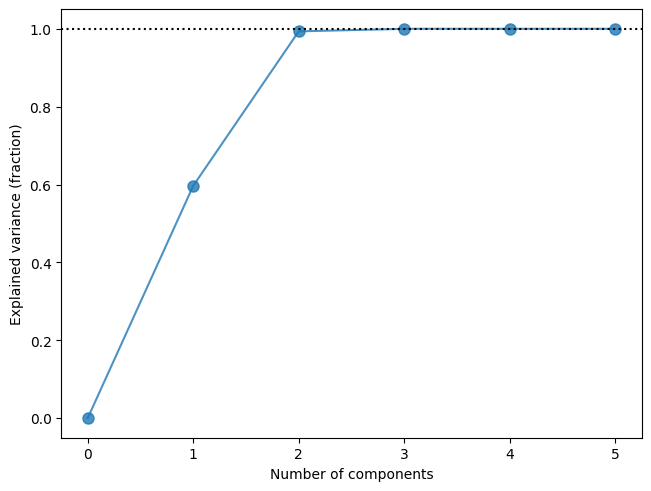

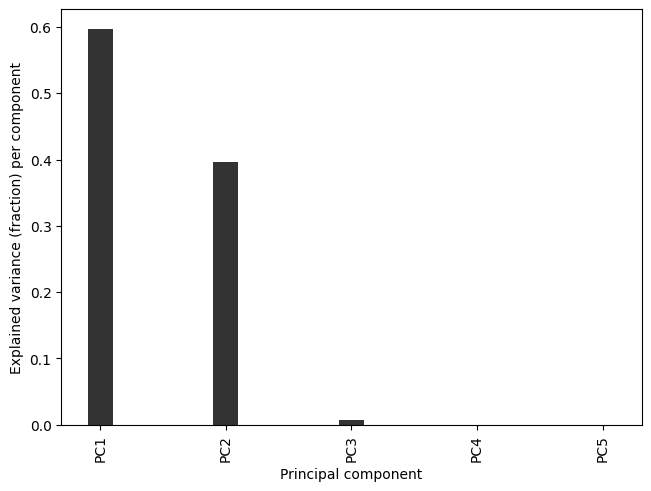

In [15]:
# perform PCA
from sklearn.decomposition import PCA
pca = PCA()
pca.fit(df_normalized)

from matplotlib import pyplot as plt
from psynlig import (
    pca_explained_variance,
    pca_explained_variance_bar,
)

_, ax = pca_explained_variance(pca,  marker='o', markersize=8, alpha=0.8)

plt.show()

pca_explained_variance_bar(
    pca,
    width=0.2,
    alpha=0.8,
    color='black',
)

plt.show()

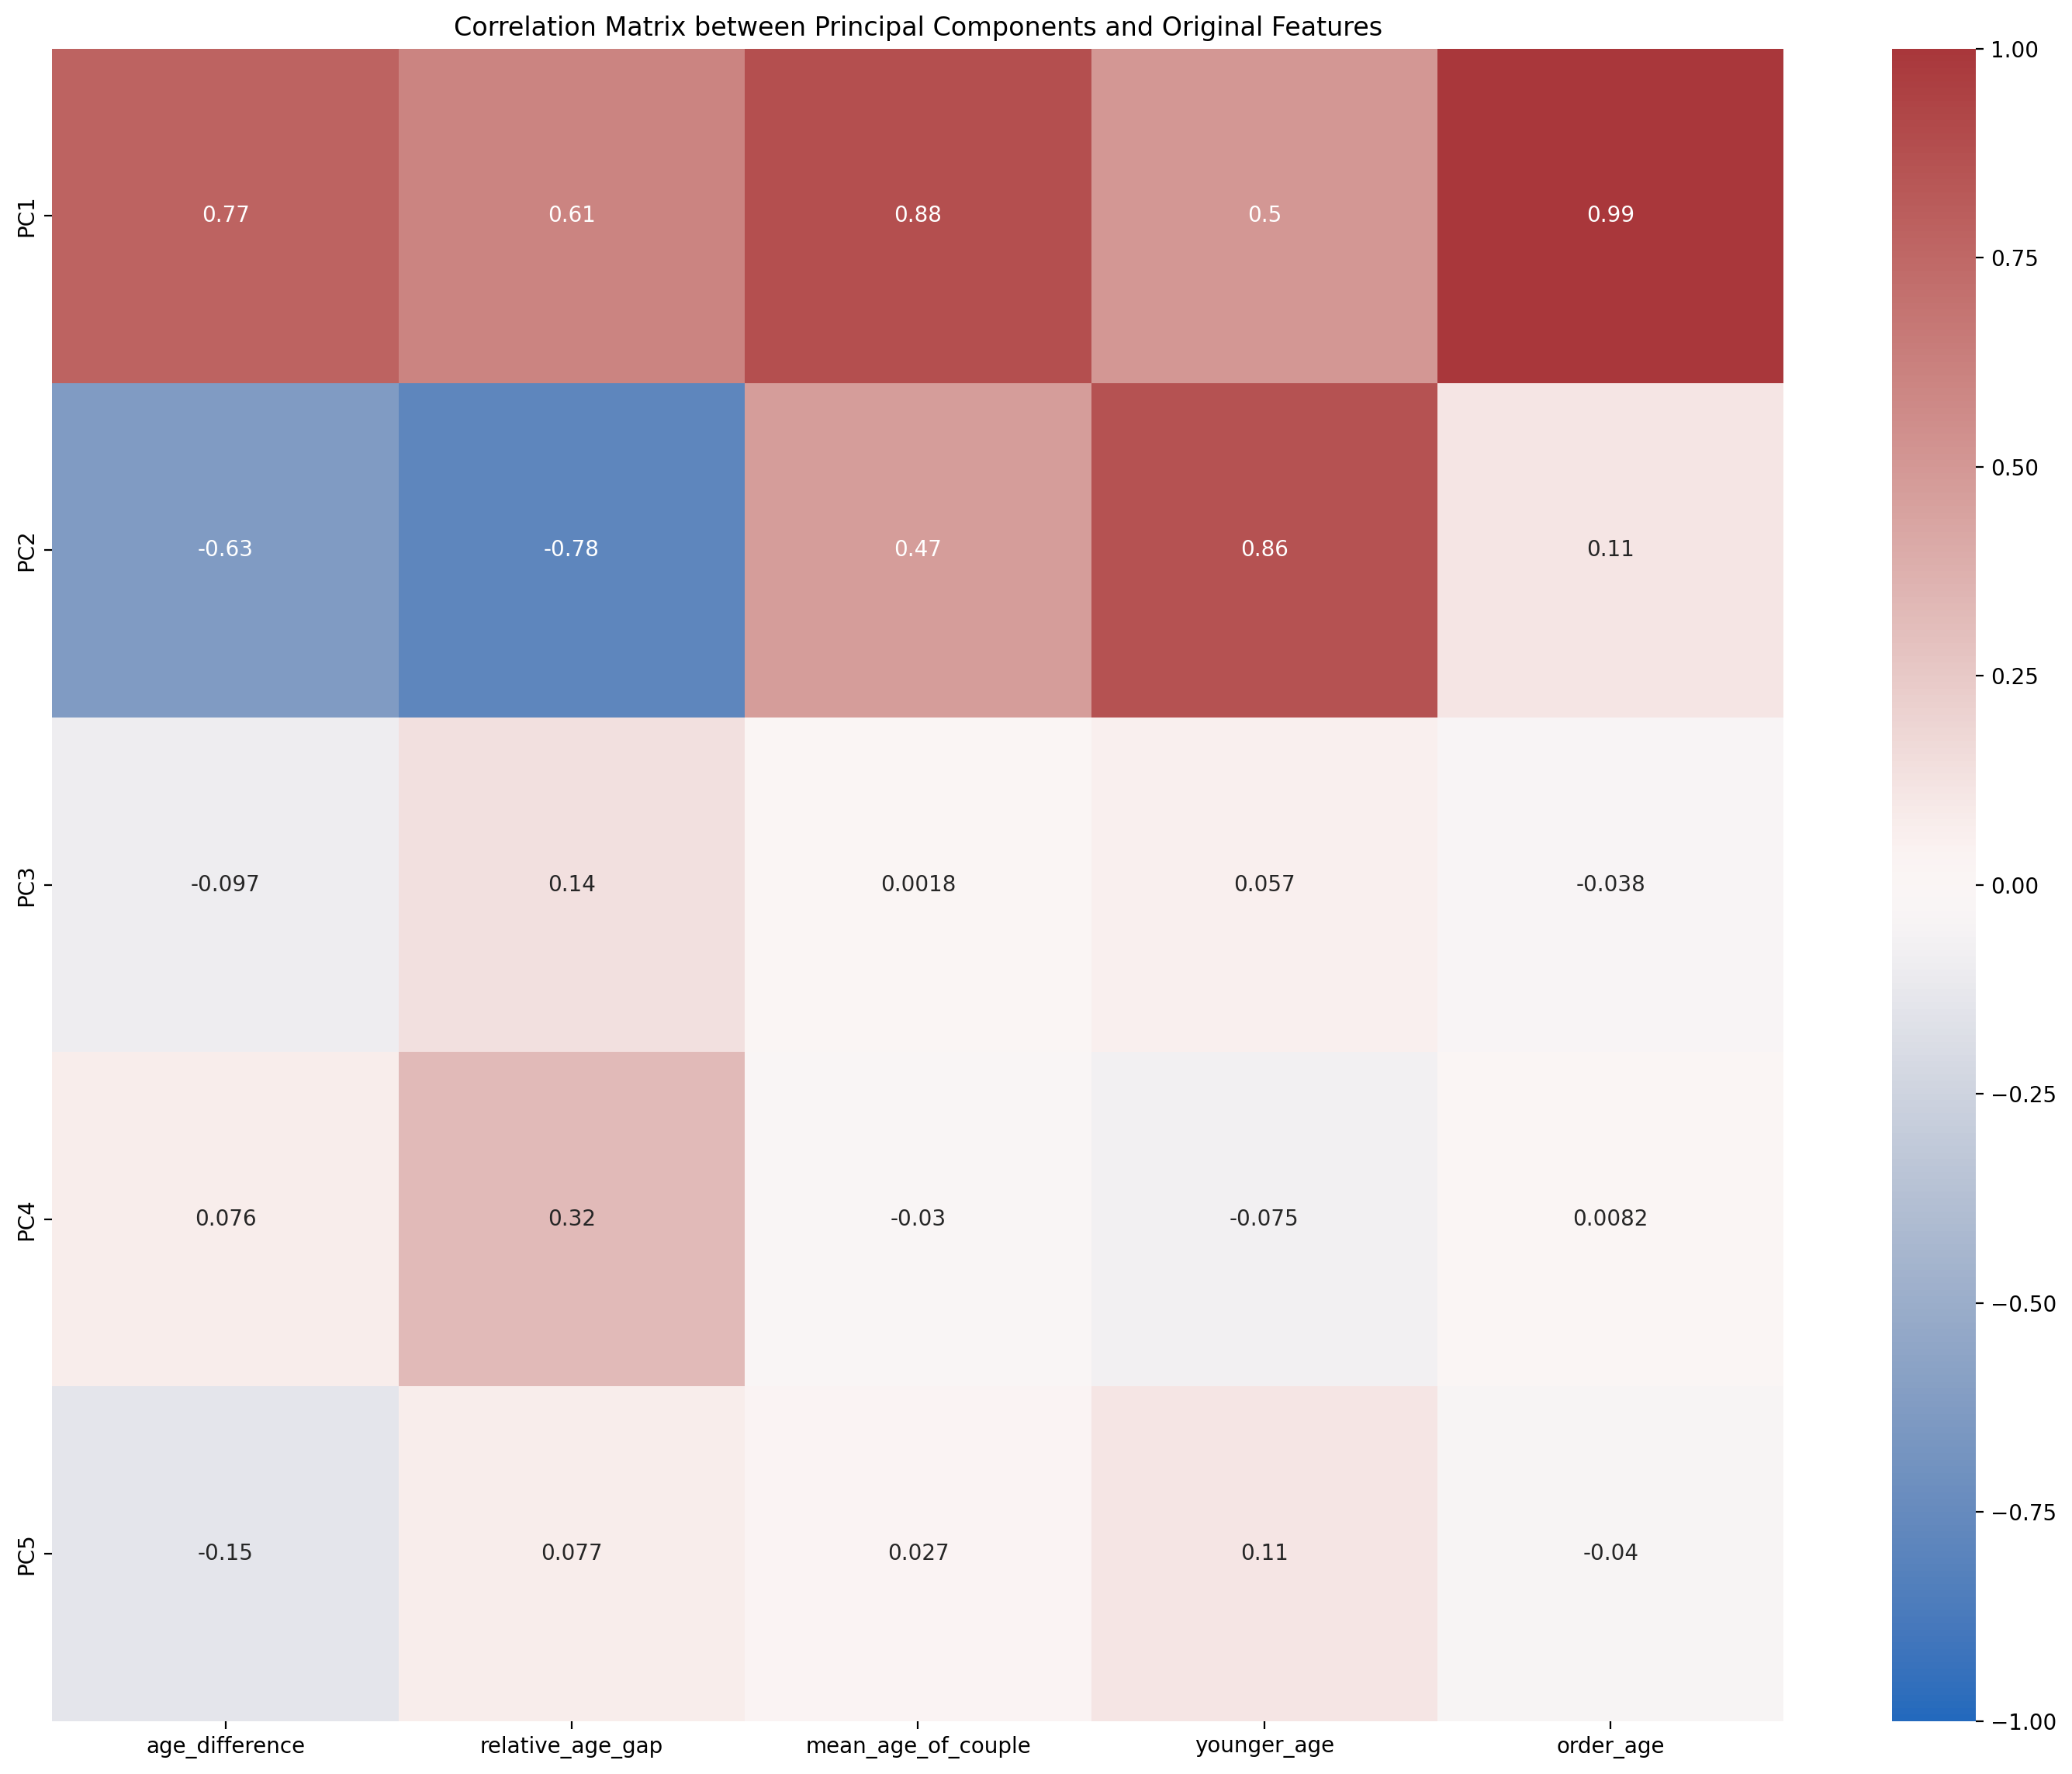

In [16]:
# Data represented in terms of PCs
transformed_data = pd.DataFrame(pca.transform(df_normalized), columns = ['PC' + str(i+1) for i in range(len(pca.components_))])

# Concatenate the PCs and the normalized original features
combined_df = pd.concat([transformed_data, df_normalized.reset_index(drop=True)], axis=1)

# Calculate the correlation matrix
correlation_pcs_original = combined_df.corr().loc[transformed_data.columns, df_normalized.columns]

plt.figure(figsize=(18, 14), dpi=200)
sns.heatmap(correlation_pcs_original, annot=True, cmap='vlag', vmin=-1, vmax=1)
plt.title('Correlation Matrix between Principal Components and Original Features')
plt.show()

Since PC1 and PC2 can explain more than 90% variance, we only keep these two PC to do further analysis.

([<Figure size 640x480 with 1 Axes>, <Figure size 640x480 with 1 Axes>],
 [<Axes: title={'center': 'Loading coefficients for PC1'}, xlabel='Variables', ylabel='Coefficient'>,
  <Axes: title={'center': 'Loading coefficients for PC2'}, xlabel='Variables', ylabel='Coefficient'>])

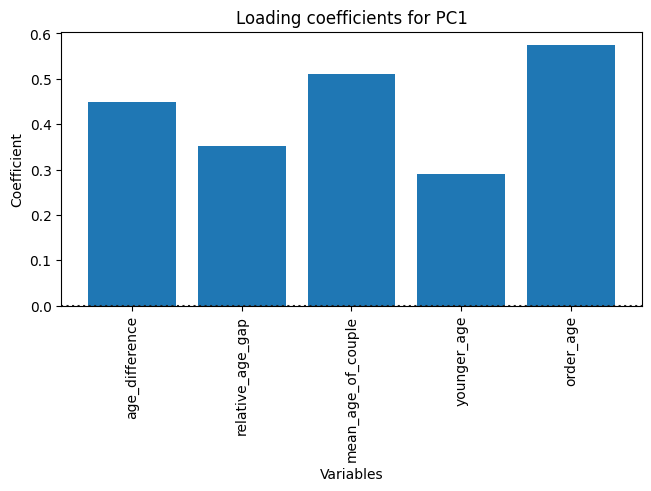

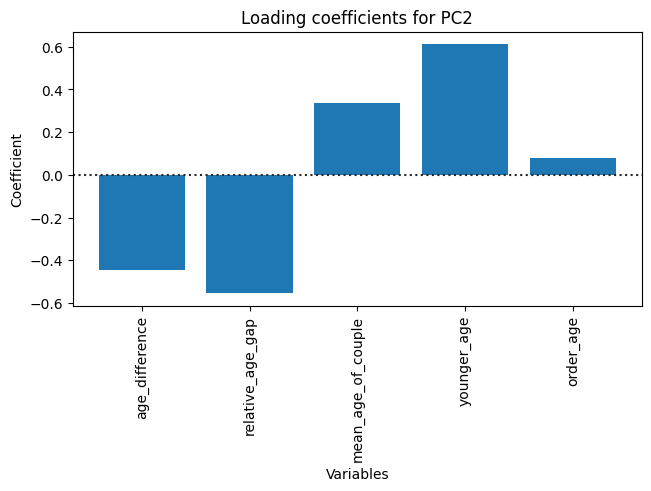

In [17]:
from psynlig import pca_1d_loadings

pca_1d_loadings(
    pca,
    df_normalized.columns,
    select_components={1, 2},
    plot_type="bar",
)

#K-means Cluster

In [18]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(df_normalized)

In [19]:
#Transfer PC to dataframe
import pandas as pd

df_pca = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"],
    index=age_gaps_copy.index
)

df_pca.head()

,PC1,PC2
0,6.597858,-4.969762
1,6.294545,-4.505052
2,5.899592,-5.596970
3,5.308986,-4.313343
4,6.549668,-0.968308


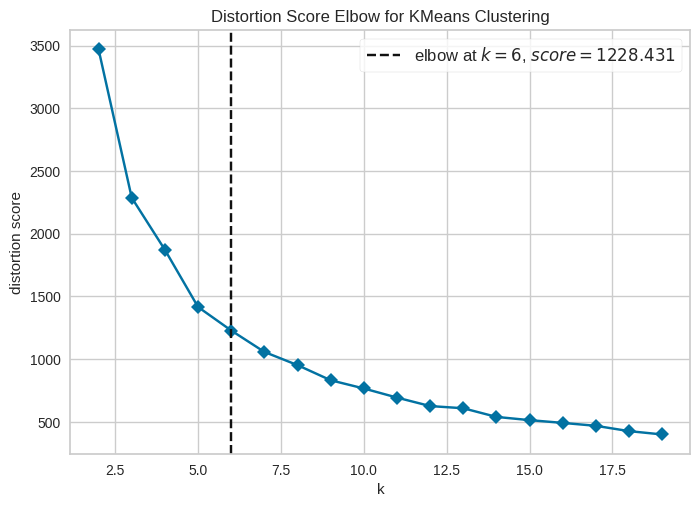

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [20]:
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer

clustering = KMeans(random_state=42)
visualizer = KElbowVisualizer(
    clustering, k=(2, 20), metric='distortion', timings=False, random_state=42
)

visualizer.fit(df_pca)
visualizer.show()

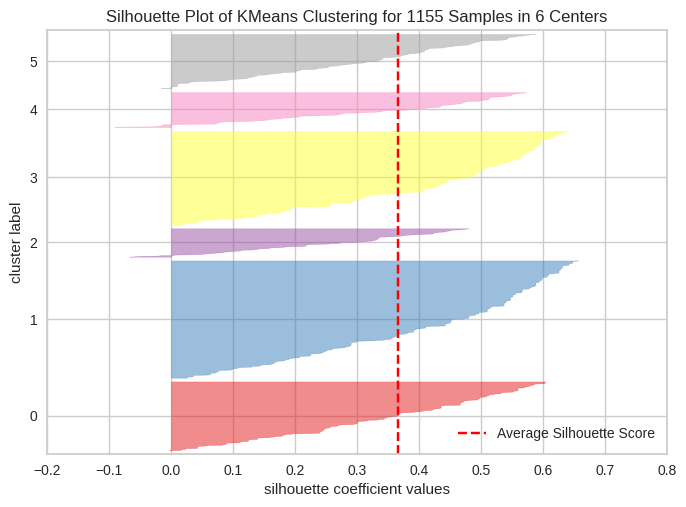

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 1155 Samples in 6 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [21]:
from yellowbrick.cluster import SilhouetteVisualizer
n_clusters_kmeans=6

kmeans_model = KMeans(n_clusters_kmeans, random_state=42)
visualizer = SilhouetteVisualizer(kmeans_model, timings=False)

visualizer.fit(df_pca)
visualizer.show()

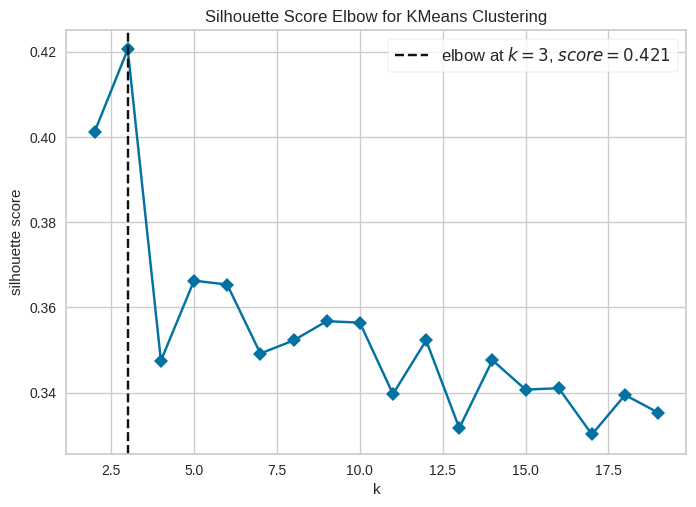

<Axes: title={'center': 'Silhouette Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='silhouette score'>

In [22]:
clustering = KMeans(random_state=42)
visualizer = KElbowVisualizer(
    clustering, k=(2, 20), metric='silhouette', timings=False, random_state=42
)

visualizer.fit(df_pca)
visualizer.show()

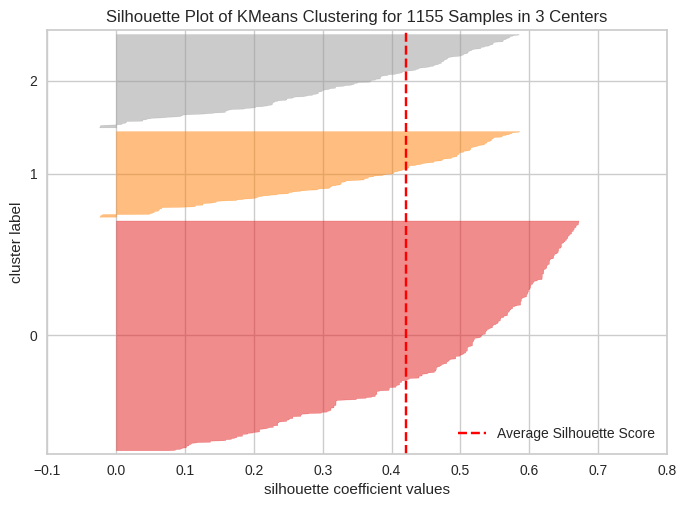

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 1155 Samples in 3 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [23]:
from yellowbrick.cluster import SilhouetteVisualizer
n_clusters_kmeans=3

kmeans_model = KMeans(n_clusters_kmeans, random_state=42)
visualizer = SilhouetteVisualizer(kmeans_model, timings=False)

visualizer.fit(df_pca)        # Fit the data to the visualizer
visualizer.show()

In [24]:
n_clusters_kmeans = 3

In [25]:

# Initialize KMeans model with n_clusters and random_state=42
kmeans = KMeans(n_clusters=n_clusters_kmeans, random_state=42) # Trye different number of clusters

# Fit the model and predict cluster labels, excluding the existing 'cluster_labels' column
df_normalized['cluster_labels'] = kmeans.fit_predict(df_normalized).astype(str)

# Display the value counts of the new cluster labels
print(df_normalized['cluster_labels'].value_counts())


cluster_labels
0    656
2    256
1    243
Name: count, dtype: int64


In [26]:
kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(df_pca)

df_pca["cluster"] = labels
age_gaps_copy["cluster"] = labels

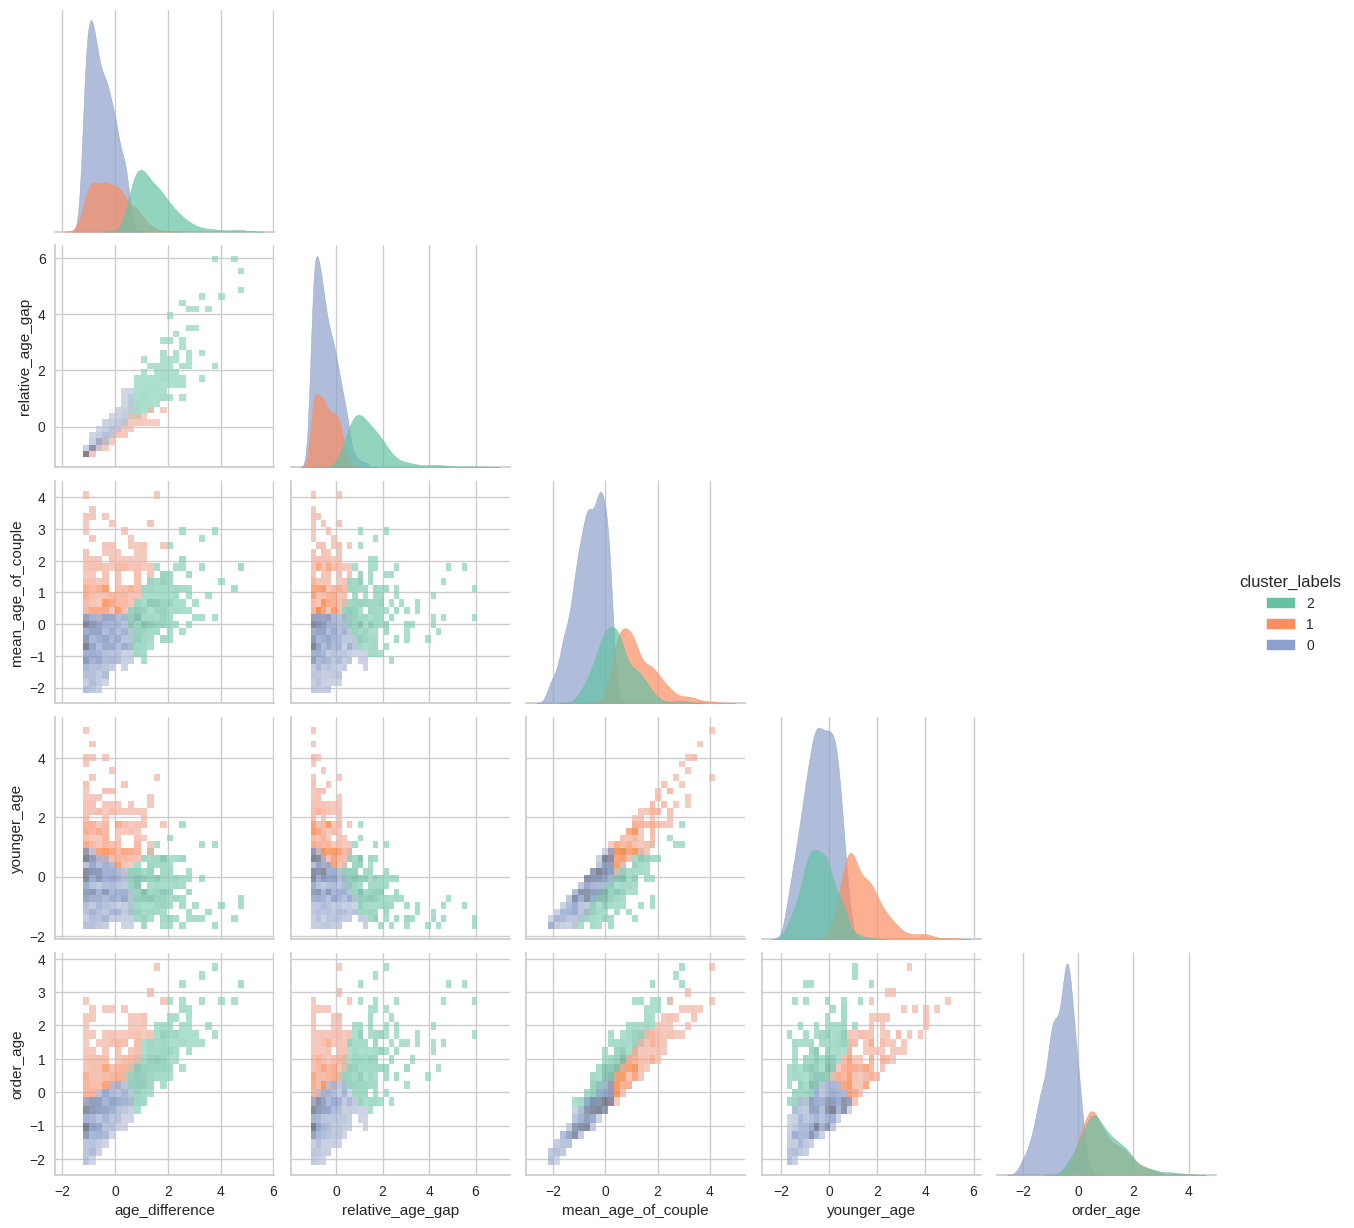

In [27]:
sns.pairplot(df_normalized, hue="cluster_labels", kind="hist", diag_kind="kde", corner=True, palette="Set2",
    plot_kws={'alpha': 0.7}, # Adjusts transparency of the scatter points (0.0 to 1.0)
    diag_kws={'alpha': 0.7}  # Adjusts transparency of the diagonal plots (histograms/KDEs)
    )

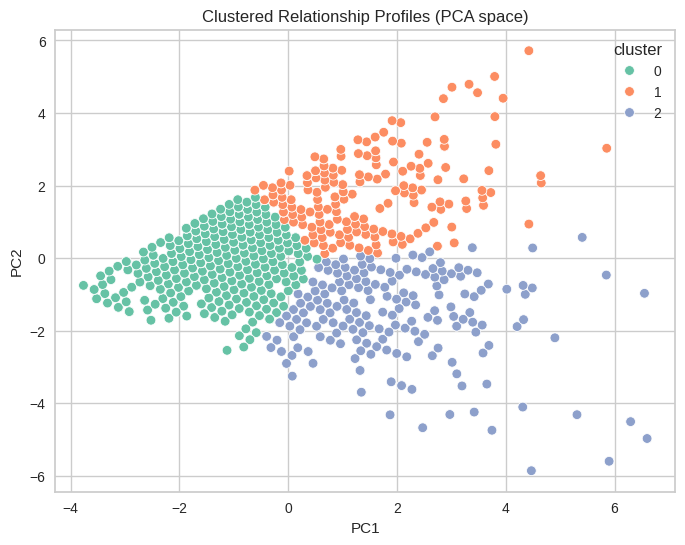

In [28]:
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(
    x="PC1",
    y="PC2",
    hue="cluster",
    data=df_pca,
    palette="Set2"
)

plt.title("Clustered Relationship Profiles (PCA space)")
plt.show()

#Evaluation

In [29]:
age_gaps_copy.groupby("cluster")[cluster_features].mean()

,age_difference,relative_age_gap,mean_age_of_couple,younger_age,order_age
cluster,,,,,
0,5.956857,0.230125,30.440678,27.462250,33.419106
1,8.909091,0.226772,45.371901,40.917355,49.826446
2,22.795455,0.870837,38.553030,27.155303,49.950758


###Define Extreme Group
The following code was developed with AI assistance. I use principal components and clustering results to identify extreme relationship profiles and examine whether these extremes are associated with production characteristics, such as repeated actor or director collaborations, across different decades. AI also helped me brainstorm how to present the relationship between extreme observations and directors or actors, and assisted with debugging when I encountered coding errors.

In [30]:
age_gaps_copy["PC1"] = X_pca[:, 0]
age_gaps_copy["PC2"] = X_pca[:, 1]

#Define the extreme 5% data points in PC2
age_gaps_copy["extreme_pc2"] = (
    age_gaps_copy["PC2"] < age_gaps_copy["PC2"].quantile(0.05)
).astype(int)

#Define cluster 2 as extreme cluster
age_gaps_copy["extreme_cluster"] = (age_gaps_copy["cluster"] == 2).astype(int)

In [31]:
pd.crosstab(
    age_gaps_copy["extreme_pc2"],
    age_gaps_copy["extreme_cluster"]
)

extreme_cluster,0,1
extreme_pc2,,
0,888,209
1,3,55


We validate that cluster 2 represents asymmetric relationships.
95% of the bottom 5% PC2 observations fall into cluster 2, suggesting that the clustering structure aligns closely with PCA-derived asymmetry.

In [32]:
#Distribution of extreme data point by decade
pd.crosstab(age_gaps_copy["by_decade"], age_gaps_copy["cluster"])

cluster,0,1,2
by_decade,,,
1930,5,0,2
1940,2,1,9
1950,10,3,21
1960,28,1,6
1970,11,4,15
1980,22,9,19
1990,139,31,52
2000,262,79,68
2010,165,106,67


In [33]:
decade_cluster = pd.crosstab(
    age_gaps_copy["by_decade"],
    age_gaps_copy["cluster"],
    normalize="index"
)

decade_cluster.round(3)

cluster,0,1,2
by_decade,,,
1930,0.714,0.000,0.286
1940,0.167,0.083,0.750
1950,0.294,0.088,0.618
1960,0.800,0.029,0.171
1970,0.367,0.133,0.500
1980,0.440,0.180,0.380
1990,0.626,0.140,0.234
2000,0.641,0.193,0.166
2010,0.488,0.314,0.198


The proportion of extreme relationship profiles (cluster 2) was highest in the 1940s and 1950s, declined substantially from the 1990s onward, and appears to be partially replaced in recent decades by cluster 1 patterns, suggesting a historical shift in how age-gap relationships are portrayed over time.

In [34]:
#Define directors who more frequently direct films with larger age differences.
director_extreme = (
    age_gaps_copy
    .groupby("director")
    .agg(
        total_movies=("extreme_pc2", "count"),
        extreme_movies=("extreme_pc2", "sum")
    )
)

director_extreme["extreme_ratio"] = (
    director_extreme["extreme_movies"] /
    director_extreme["total_movies"]
)

director_extreme = director_extreme[
    director_extreme["total_movies"] >= 5
]
director_extreme.sort_values("extreme_ratio", ascending=False).head(10)

,total_movies,extreme_movies,extreme_ratio
director,,,
Joel Coen,5,2,0.400000
Steven Spielberg,10,2,0.200000
Ruben Fleischer,5,1,0.200000
"Paul Weitz, Chris Weitz",5,1,0.200000
Tim Burton,6,1,0.166667
Adrian Lyne,6,1,0.166667
John Huston,6,1,0.166667
Woody Allen,20,3,0.150000
Nick Cassavetes,7,1,0.142857


In [35]:
#Define directors who more frequently direct films with larger age differences.
actors_extreme = (
    age_gaps_copy
    .groupby("actor_1_name")
    .agg(
        total_movies=("extreme_pc2", "count"),
        extreme_movies=("extreme_pc2", "sum")
    )
)

actors_extreme["extreme_ratio"] = (
    actors_extreme["extreme_movies"] /
    actors_extreme["total_movies"]
)

actors_extreme = actors_extreme[
    actors_extreme["total_movies"] >= 5
]
actors_extreme.sort_values("extreme_ratio", ascending=False).head(10)

,total_movies,extreme_movies,extreme_ratio
actor_1_name,,,
Humphrey Bogart,9,5,0.555556
Woody Allen,7,2,0.285714
Billy Bob Thornton,5,1,0.200000
Bill Murray,5,1,0.200000
Ralph Fiennes,5,1,0.200000
Robert De Niro,5,1,0.200000
Julianne Moore,6,1,0.166667
Paul Newman,6,1,0.166667
Cary Grant,6,1,0.166667


In [36]:
#Define directors who more frequently direct films with larger age differences.
actors_extreme2 = (
    age_gaps_copy
    .groupby("actor_2_name")
    .agg(
        total_movies=("extreme_pc2", "count"),
        extreme_movies=("extreme_pc2", "sum")
    )
)

actors_extreme2["extreme_ratio"] = (
    actors_extreme2["extreme_movies"] /
    actors_extreme2["total_movies"]
)

actors_extreme2 = actors_extreme2[
    actors_extreme2["total_movies"] >= 5
]
actors_extreme2.sort_values("extreme_ratio", ascending=False).head(10)

,total_movies,extreme_movies,extreme_ratio
actor_2_name,,,
Kate Bosworth,5,1,0.200000
Grace Kelly,6,1,0.166667
Kirsten Dunst,6,1,0.166667
Keira Knightley,13,2,0.153846
Scarlett Johansson,13,2,0.153846
Emily Blunt,7,1,0.142857
Amanda Seyfried,8,1,0.125000
Audrey Hepburn,8,1,0.125000
Drew Barrymore,9,1,0.111111


In [37]:
age_gaps_copy["extreme_pc2"].mean()

np.float64(0.050216450216450215)

Extreme relationship profiles account for only about 5% of all films, yet several directors exhibit higher extreme ratios than this baseline. This suggests that large age-gap portrayals are concentrated among specific filmmakers rather than being evenly distributed over time.